## 1.0 — Setup: Install any missing packages
(Most of these already come pre-installed on Kaggle, this just makes sure.)

In [41]:
!pip install -q imagehash


## 1.1 — Point to the dataset and check the folder structure

In [42]:
import os

# On Kaggle, added datasets live under /kaggle/input/<dataset-slug>/
BASE_DIR = "/kaggle/input/face-mask-dataset"

# Explore what's actually inside so we find the right subfolder
for root, dirs, files in os.walk(BASE_DIR):
    print(root, "->", len(files), "files", dirs)


In [43]:
# Based on the exploration above, set DATA_DIR to the folder that directly
# contains 'with_mask' and 'without_mask' subfolders.
# For this dataset it's usually: /kaggle/input/face-mask-dataset/data
DATA_DIR = "/kaggle/input/datasets/omkargurav/face-mask-dataset/data"
print(os.listdir(DATA_DIR))

['without_mask', 'with_mask']


In [44]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root, "->", len(files), "files, subdirs:", dirs)

/kaggle/input -> 0 files, subdirs: ['datasets']
/kaggle/input/datasets -> 0 files, subdirs: ['omkargurav']
/kaggle/input/datasets/omkargurav -> 0 files, subdirs: ['face-mask-dataset']
/kaggle/input/datasets/omkargurav/face-mask-dataset -> 0 files, subdirs: ['data']
/kaggle/input/datasets/omkargurav/face-mask-dataset/data -> 0 files, subdirs: ['without_mask', 'with_mask']
/kaggle/input/datasets/omkargurav/face-mask-dataset/data/without_mask -> 3828 files, subdirs: []
/kaggle/input/datasets/omkargurav/face-mask-dataset/data/with_mask -> 3725 files, subdirs: []


## 1.2 — Load and explore: shape, structure, class counts

In [45]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLASSES = ["with_mask", "without_mask"]

# Build a dataframe of filepath -> label (this is our 'dataset table' equivalent for images)
records = []
for cls in CLASSES:
    folder = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(folder):
        records.append({"filepath": os.path.join(folder, fname), "label": cls})

df = pd.DataFrame(records)
print("Total images found:", len(df))
df.head()


Total images found: 7553


,filepath,label
0,/kaggle/input/datasets/omkargurav/face-mask-da...,with_mask
1,/kaggle/input/datasets/omkargurav/face-mask-da...,with_mask
2,/kaggle/input/datasets/omkargurav/face-mask-da...,with_mask
3,/kaggle/input/datasets/omkargurav/face-mask-da...,with_mask
4,/kaggle/input/datasets/omkargurav/face-mask-da...,with_mask


In [46]:
# Shape / class balance summary
print("Shape of metadata table:", df.shape)
print()
print("Class counts:")
print(df["label"].value_counts())
print()
print("Class percentages:")
print(df["label"].value_counts(normalize=True) * 100)


Shape of metadata table: (7553, 2)

Class counts:
label
without_mask    3828
with_mask       3725
Name: count, dtype: int64

Class percentages:
label
without_mask    50.681848
with_mask       49.318152
Name: proportion, dtype: float64


In [47]:
# Inspect a sample of actual images: dimensions, dtype, color mode
sample_paths = df.sample(10, random_state=42)["filepath"].tolist()

print(f"{'filename':40s} {'shape':15s} {'dtype':10s}")
for p in sample_paths:
    img = cv2.imread(p)
    if img is None:
        print(f"{os.path.basename(p):40s} FAILED TO LOAD")
        continue
    print(f"{os.path.basename(p):40s} {str(img.shape):15s} {str(img.dtype):10s}")


filename                                 shape           dtype     
with_mask_3304.jpg                       (1876, 2500, 3) uint8     
with_mask_758.jpg                        (350, 233, 3)   uint8     
with_mask_196.jpg                        (232, 177, 3)   uint8     
with_mask_2070.jpg                       (400, 273, 3)   uint8     
with_mask_680.jpg                        (137, 89, 3)    uint8     
without_mask_3606.jpg                    (434, 321, 3)   uint8     
with_mask_373.jpg                        (88, 62, 3)     uint8     
without_mask_2997.jpg                    (275, 183, 3)   uint8     
with_mask_1704.jpg                       (448, 353, 3)   uint8     
without_mask_823.jpg                     (428, 320, 3)   uint8     


In [48]:
# Identify data type / format mismatches: file extensions, color modes, corrupted files
from collections import Counter

ext_counts = Counter(os.path.splitext(p)[1].lower() for p in df["filepath"])
print("File extensions found:", ext_counts)

bad_files = []
shapes = []
for p in df["filepath"]:
    img = cv2.imread(p)
    if img is None:
        bad_files.append(p)
    else:
        shapes.append(img.shape)

print(f"\nUnreadable/corrupted files: {len(bad_files)} out of {len(df)}")
channel_counts = Counter(s[2] if len(s) == 3 else 1 for s in shapes)
print("Channel counts across images (3=RGB, 1=grayscale, 4=RGBA):", channel_counts)


File extensions found: Counter({'.jpg': 7553})

Unreadable/corrupted files: 0 out of 7553
Channel counts across images (3=RGB, 1=grayscale, 4=RGBA): Counter({3: 7553})


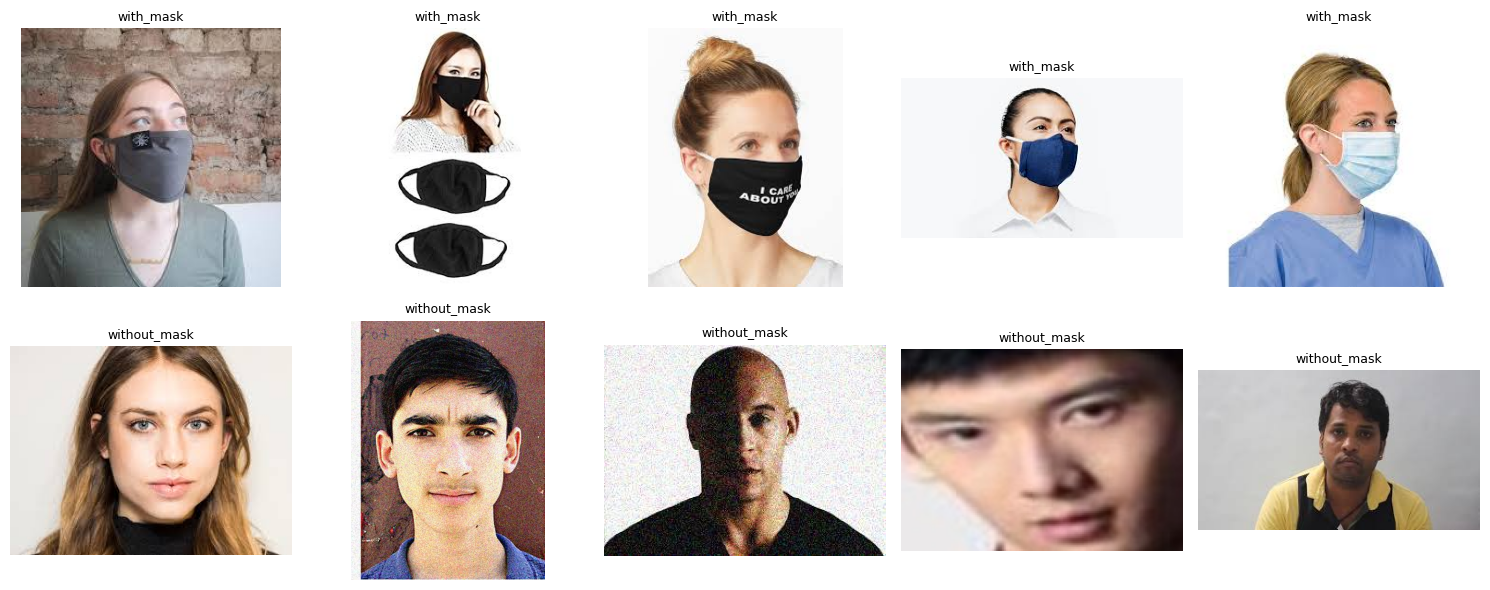

In [49]:
# Visual sample grid — one quick look at what we're working with
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(CLASSES):
    cls_samples = df[df["label"] == cls].sample(5, random_state=1)["filepath"].tolist()
    for j, p in enumerate(cls_samples):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls, fontsize=9)
        axes[i, j].axis("off")
plt.tight_layout()
plt.show()


In [50]:
!pip install -q imagehash
import imagehash
from PIL import Image
from collections import defaultdict

In [51]:
hashes = {}
for p in df["filepath"]:
    try:
        h = imagehash.phash(Image.open(p))
        hashes[p] = h
    except Exception as e:
        print(f"Could not hash {p}: {e}")

df["phash"] = df["filepath"].map(hashes)
print("Hashed", len(hashes), "images")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Hashed 7553 images


In [52]:
exact_dupe_groups = defaultdict(list)
for p, h in hashes.items():
    exact_dupe_groups[str(h)].append(p)

exact_dupes = {h: paths for h, paths in exact_dupe_groups.items() if len(paths) > 1}
n_exact_dupe_files = sum(len(paths) - 1 for paths in exact_dupes.values())  # extras beyond the first

print(f"Exact duplicate groups: {len(exact_dupes)}")
print(f"Total duplicate files to drop: {n_exact_dupe_files} ({n_exact_dupe_files/len(df)*100:.2f}% of dataset)")

Exact duplicate groups: 488
Total duplicate files to drop: 657 (8.70% of dataset)


In [53]:
files_to_drop = []
for paths in exact_dupes.values():
    files_to_drop.extend(paths[1:])  # keep first, drop the rest

df_clean = df[~df["filepath"].isin(files_to_drop)].reset_index(drop=True)
print("Before:", len(df), "After removing duplicates:", len(df_clean))

Before: 7553 After removing duplicates: 6896


In [54]:
import cv2

bad_files = []
for p in df_clean["filepath"]:
    img = cv2.imread(p)
    if img is None:
        bad_files.append(p)

pct_bad = len(bad_files) / len(df_clean) * 100
print(f"Corrupted/unreadable files: {len(bad_files)} ({pct_bad:.2f}% of dataset)")

Corrupted/unreadable files: 0 (0.00% of dataset)


In [55]:
if pct_bad < 5:
    df_clean2 = df_clean[~df_clean["filepath"].isin(bad_files)].reset_index(drop=True)
    print("Dropped corrupted files. Before:", len(df_clean), "After:", len(df_clean2))
else:
    print("More than 5% corrupted — investigate before dropping.")
    df_clean2 = df_clean.copy()

Dropped corrupted files. Before: 6896 After: 6896


In [56]:
if len(bad_files) > 0:
    for p in bad_files[:10]:
        size = os.path.getsize(p) if os.path.exists(p) else "MISSING FILE"
        print(p, "-> size:", size, "bytes")
else:
    print("No corrupted files found — nothing to investigate.")

No corrupted files found — nothing to investigate.


In [57]:
exact_dupe_groups = defaultdict(list)
for p, h in hashes.items():
    exact_dupe_groups[str(h)].append(p)

exact_dupes = {h: paths for h, paths in exact_dupe_groups.items() if len(paths) > 1}
n_exact_dupe_files = sum(len(paths) - 1 for paths in exact_dupes.values())  # extras beyond the first

print(f"Exact duplicate groups: {len(exact_dupes)}")
print(f"Total duplicate files to drop: {n_exact_dupe_files} ({n_exact_dupe_files/len(df)*100:.2f}% of dataset)")

Exact duplicate groups: 488
Total duplicate files to drop: 657 (8.70% of dataset)


In [58]:
files_to_drop = []
for paths in exact_dupes.values():
    files_to_drop.extend(paths[1:])  # keep first, drop the rest

df_clean = df[~df["filepath"].isin(files_to_drop)].reset_index(drop=True)
print("Before:", len(df), "After removing duplicates:", len(df_clean))

Before: 7553 After removing duplicates: 6896


In [59]:
phash_list = list(hashes.items())
near_dupe_pairs = []

for i in range(len(phash_list)):
    for j in range(i + 1, len(phash_list)):
        p1, h1 = phash_list[i]
        p2, h2 = phash_list[j]
        dist = h1 - h2
        if 0 < dist <= 5:
            near_dupe_pairs.append((p1, p2, dist))

print(f"Near-duplicate pairs found: {len(near_dupe_pairs)}")
# NOTE: O(n^2) — can be slow on 7500+ images. If it hangs, skip this cell;
# exact-duplicate removal is usually sufficient for this dataset.

Near-duplicate pairs found: 359


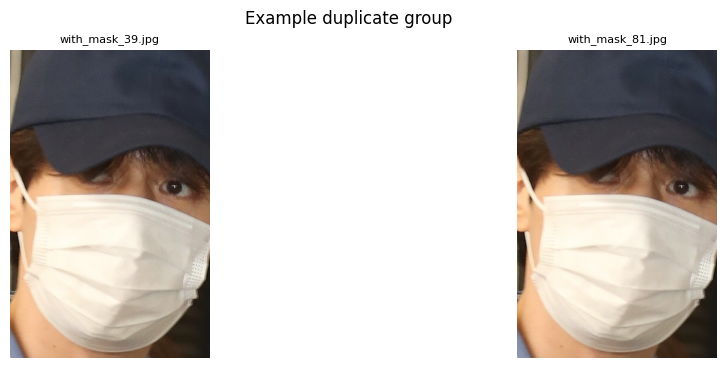

In [60]:
import matplotlib.pyplot as plt

if len(exact_dupes) > 0:
    sample_group = list(exact_dupes.values())[0]
    fig, axes = plt.subplots(1, len(sample_group[:4]), figsize=(12, 4))
    if len(sample_group[:4]) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample_group[:4]):
        img = plt.imread(p)
        ax.imshow(img)
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis("off")
    plt.suptitle("Example duplicate group")
    plt.show()
else:
    print("No exact duplicates to visualize.")

In [61]:
import numpy as np
from tqdm import tqdm

stats = []
for p in tqdm(df_clean2["filepath"]):
    img = cv2.imread(p)
    h, w = img.shape[:2]
    brightness = img.mean()
    stats.append({"filepath": p, "width": w, "height": h, "aspect_ratio": w/h, "brightness": brightness})

stats_df = pd.DataFrame(stats)
df_clean2 = df_clean2.merge(stats_df, on="filepath")
df_clean2[["width", "height", "aspect_ratio", "brightness"]].describe()

100%|██████████| 6896/6896 [00:16<00:00, 424.33it/s]


,width,height,aspect_ratio,brightness
count,6896.000000,6896.000000,6896.000000,6896.000000
mean,257.002175,264.537703,0.997302,135.245091
std,281.994384,264.062502,0.336314,37.639700
min,26.000000,37.000000,0.345238,11.130373
25%,147.000000,141.000000,0.747664,109.768392
50%,201.000000,224.000000,0.986726,134.770006
75%,275.000000,275.000000,1.125000,160.839453
max,5760.000000,5412.000000,3.023256,250.807578


In [62]:
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return (series < lower) | (series > upper)

outlier_mask = (
    iqr_outliers(df_clean2["aspect_ratio"]) |
    iqr_outliers(df_clean2["brightness"])
)
print(f"Outliers detected: {outlier_mask.sum()} ({outlier_mask.sum()/len(df_clean2)*100:.2f}% of dataset)")

Outliers detected: 450 (6.53% of dataset)


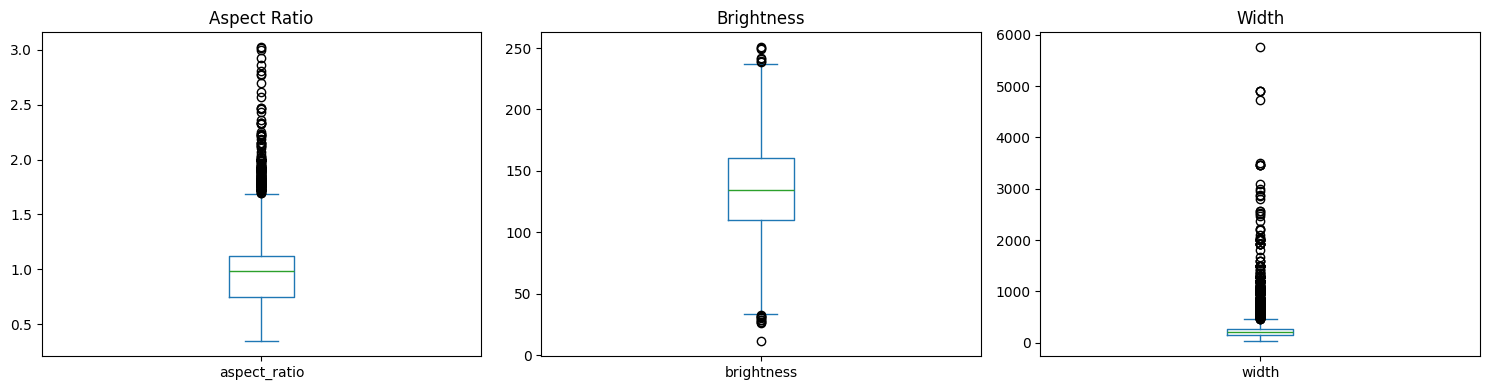

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_clean2["aspect_ratio"].plot(kind="box", ax=axes[0], title="Aspect Ratio")
df_clean2["brightness"].plot(kind="box", ax=axes[1], title="Brightness")
df_clean2["width"].plot(kind="box", ax=axes[2], title="Width")
plt.tight_layout()
plt.show()

In [64]:
extreme_brightness = df_clean2[(df_clean2["brightness"] < 10) | (df_clean2["brightness"] > 245)]
print(f"Extreme brightness outliers: {len(extreme_brightness)}")

df_final = df_clean2[~df_clean2["filepath"].isin(extreme_brightness["filepath"])].reset_index(drop=True)
print("Before:", len(df_clean2), "After removing extreme-brightness outliers:", len(df_final))

Extreme brightness outliers: 3
Before: 6896 After removing extreme-brightness outliers: 6893


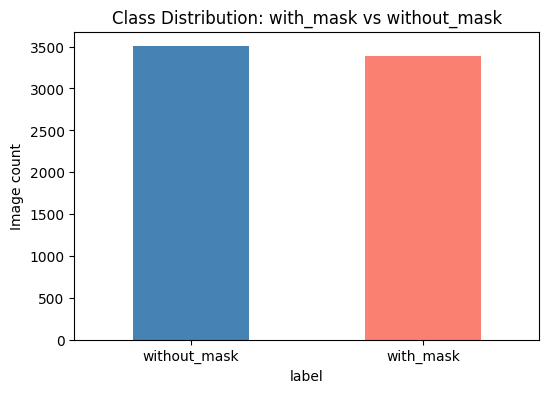

label
without_mask    50.83418
with_mask       49.16582
Name: proportion, dtype: float64


In [65]:
plt.figure(figsize=(6,4))
df_final["label"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Class Distribution: with_mask vs without_mask")
plt.ylabel("Image count")
plt.xticks(rotation=0)
plt.show()

print(df_final["label"].value_counts(normalize=True) * 100)

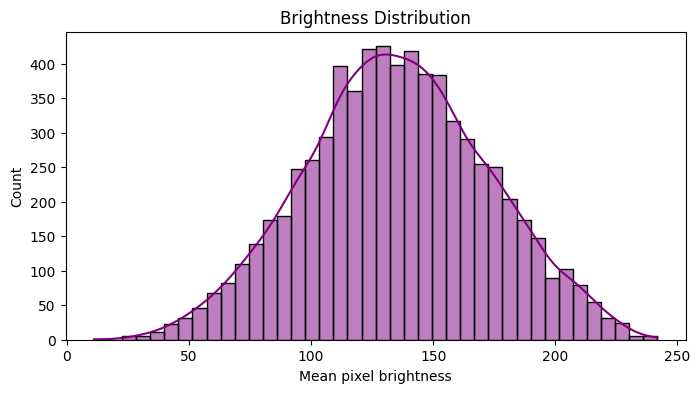

In [66]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_final["brightness"], kde=True, bins=40, color="purple")
plt.title("Brightness Distribution")
plt.xlabel("Mean pixel brightness")
plt.show()

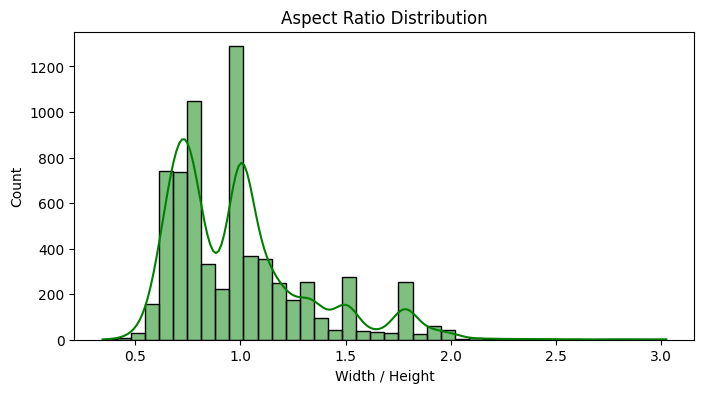

In [67]:
plt.figure(figsize=(8,4))
sns.histplot(df_final["aspect_ratio"], kde=True, bins=40, color="green")
plt.title("Aspect Ratio Distribution")
plt.xlabel("Width / Height")
plt.show()

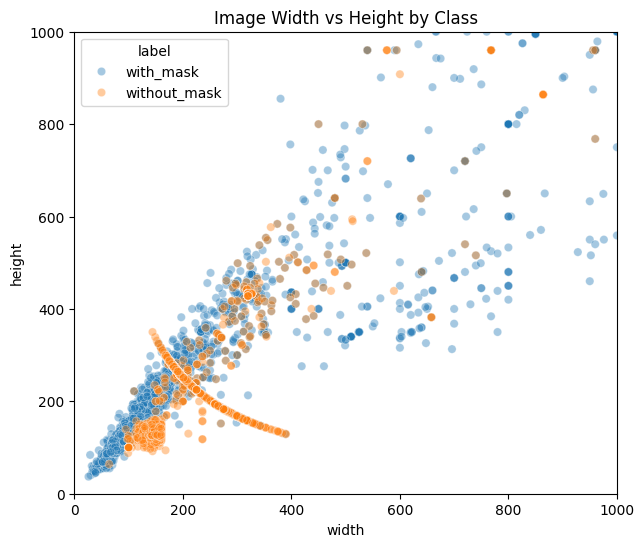

In [68]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df_final, x="width", y="height", hue="label", alpha=0.4)
plt.title("Image Width vs Height by Class")
plt.xlim(0, 1000)  # zoom in, since a few huge outliers will otherwise squash the plot
plt.ylim(0, 1000)
plt.show()

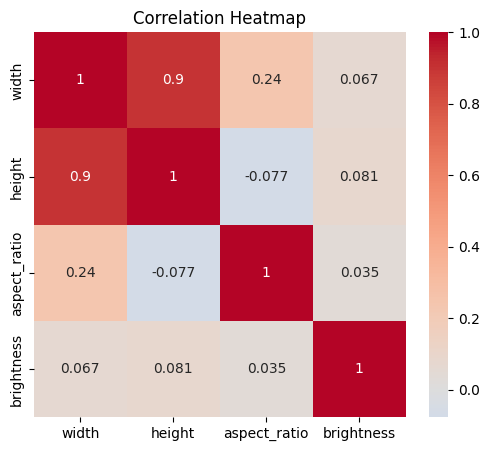

In [69]:
plt.figure(figsize=(6,5))
corr = df_final[["width", "height", "aspect_ratio", "brightness"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

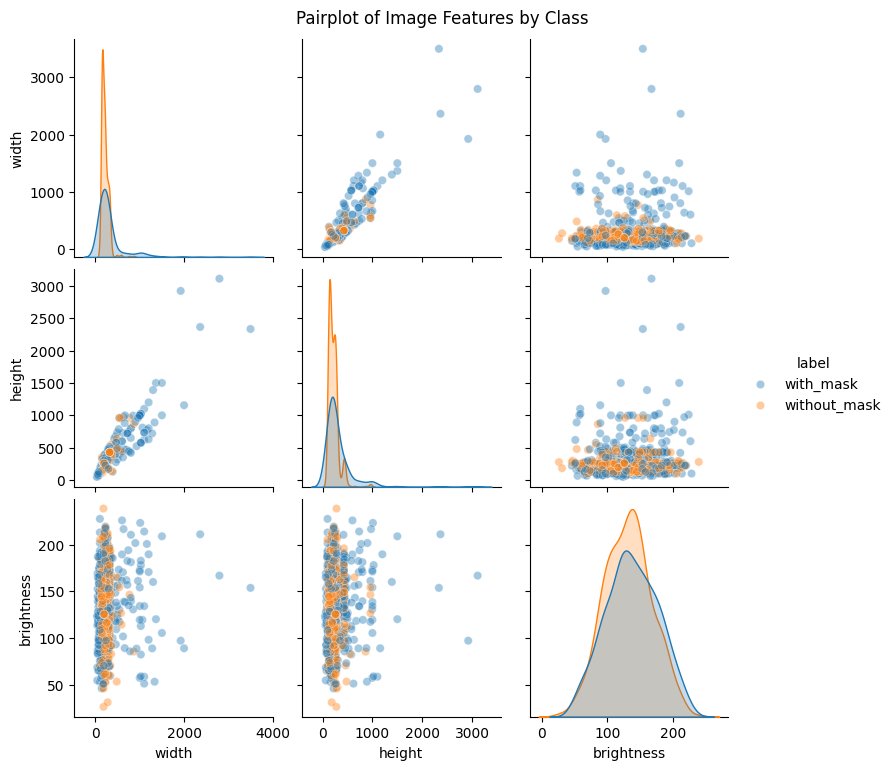

In [70]:
sns.pairplot(df_final[["width", "height", "brightness", "label"]].sample(1000, random_state=1),
             hue="label", plot_kws={"alpha": 0.4})
plt.suptitle("Pairplot of Image Features by Class", y=1.02)
plt.show()

/tmp/ipykernel_58/2750784559.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="label", y="brightness", palette=["steelblue", "salmon"])


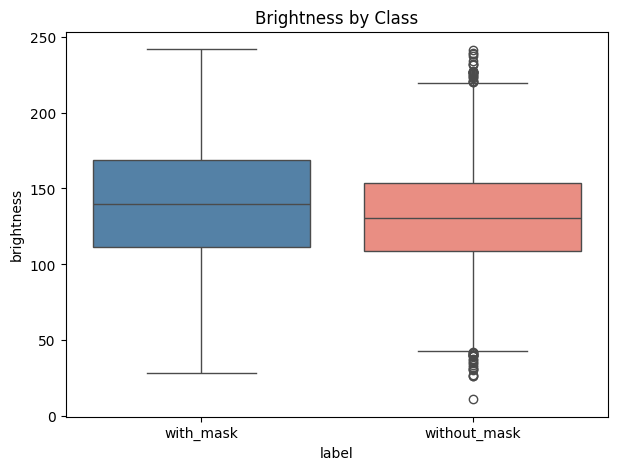

In [71]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df_final, x="label", y="brightness", palette=["steelblue", "salmon"])
plt.title("Brightness by Class")
plt.show()

In [72]:
class_pct = df_final["label"].value_counts(normalize=True) * 100
print(class_pct)

minority_pct = class_pct.min()
if minority_pct < 30:
    print(f"\nImbalanced dataset (minority class = {minority_pct:.1f}%)")
else:
    print(f"\nDataset is reasonably balanced (minority class = {minority_pct:.1f}%)")

label
without_mask    50.83418
with_mask       49.16582
Name: proportion, dtype: float64

Dataset is reasonably balanced (minority class = 49.2%)


In [73]:
from sklearn.utils.class_weight import compute_class_weight

classes = df_final["label"].unique()
y = df_final["label"].values

class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
label_to_idx = {label: i for i, label in enumerate(classes)}

print("Classes:", label_to_idx)
print("Class weights:", class_weight_dict)

Classes: {'with_mask': 0, 'without_mask': 1}
Class weights: {0: np.float64(1.0169666568309235), 1: np.float64(0.9835901826484018)}


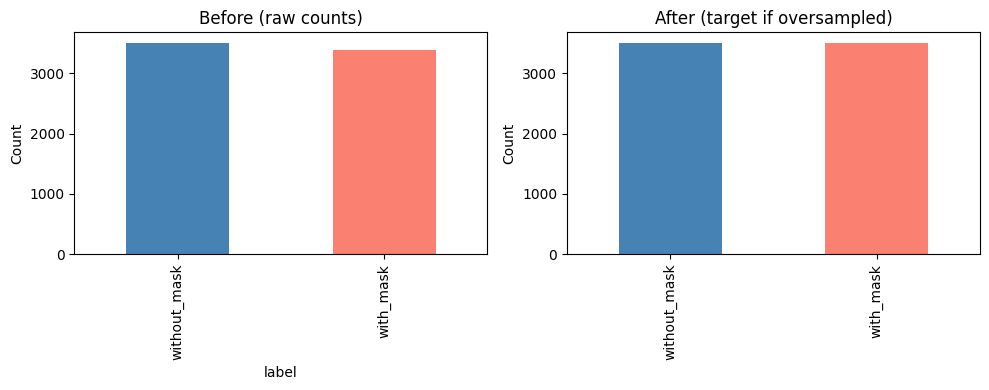

In [74]:
counts = df_final["label"].value_counts()
max_count = counts.max()

fig, axes = plt.subplots(1, 2, figsize=(10,4))
counts.plot(kind="bar", ax=axes[0], color=["steelblue","salmon"], title="Before (raw counts)")
axes[0].set_ylabel("Count")

balanced_counts = pd.Series({cls: max_count for cls in counts.index})
balanced_counts.plot(kind="bar", ax=axes[1], color=["steelblue","salmon"], title="After (target if oversampled)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [75]:
# We'll pass class_weight_dict into model.fit() later (Step 7) rather than physically oversampling files.
# This is the standard, recommended approach for image classification imbalance.
print("Strategy: use class_weight_dict during training + standard data augmentation (rotation/flip/zoom)")
print("No files are duplicated on disk — weighting happens inside the loss function.")

Strategy: use class_weight_dict during training + standard data augmentation (rotation/flip/zoom)
No files are duplicated on disk — weighting happens inside the loss function.


In [76]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_final, test_size=0.3, stratify=df_final["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

Train: 4825 Val: 1034 Test: 1034


In [77]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

print(train_gen.class_indices)

Found 4825 validated image filenames belonging to 2 classes.
Found 1034 validated image filenames belonging to 2 classes.
Found 1034 validated image filenames belonging to 2 classes.
{'with_mask': 0, 'without_mask': 1}


In [78]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze base for initial training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)  # helps prevent overfitting
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [79]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15


2026-08-08 15:36:11.955300: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 15:36:12.092808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1786203374.200756     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 14/151 ━━━━━━━━━━━━━━━━━━━━ 51s 378ms/step - accuracy: 0.5136 - loss: 0.8026

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


 45/151 ━━━━━━━━━━━━━━━━━━━━ 41s 392ms/step - accuracy: 0.6449 - loss: 0.6368

2026-08-08 15:36:40.893501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 15:36:41.035552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 15:36:41.172150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.7978 - loss: 0.4139

2026-08-08 15:37:40.424380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 15:37:40.563178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


151/151 ━━━━━━━━━━━━━━━━━━━━ 106s 587ms/step - accuracy: 0.9059 - loss: 0.2384 - val_accuracy: 0.9691 - val_loss: 0.1040
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 418ms/step - accuracy: 0.9733 - loss: 0.0834 - val_accuracy: 0.9662 - val_loss: 0.0850
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 418ms/step - accuracy: 0.9801 - loss: 0.0607 - val_accuracy: 0.9710 - val_loss: 0.0684
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 419ms/step - accuracy: 0.9799 - loss: 0.0537 - val_accuracy: 0.9710 - val_loss: 0.0671
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 65s 428ms/step - accuracy: 0.9818 - loss: 0.0507 - val_accuracy: 0.9729 - val_loss: 0.0603
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 415ms/step - accuracy: 0.9888 - loss: 0.0408 - val_accuracy: 0.9797 - val_loss: 0.0481
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 414ms/step - accuracy: 0.9845 - loss: 0.0429 - val_accuracy: 0.9768 - val_loss: 0.0517
Epoch 8/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 63s 417ms/step - accuracy: 0.9874 - loss: 0.0391 - va

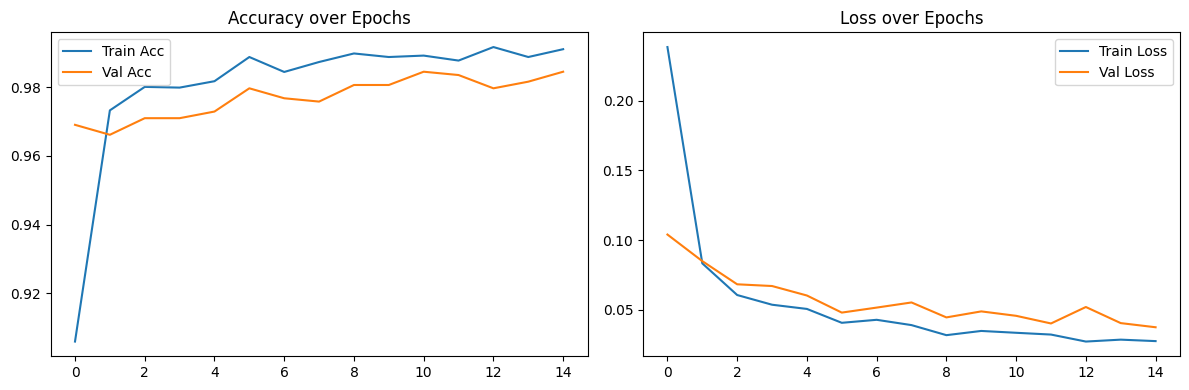

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history["accuracy"], label="Train Acc")
axes[0].plot(history.history["val_accuracy"], label="Val Acc")
axes[0].set_title("Accuracy over Epochs")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [82]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
gap = final_train_acc - final_val_acc

print(f"Train acc: {final_train_acc:.4f} | Val acc: {final_val_acc:.4f} | Gap: {gap:.4f}")
if gap > 0.1:
    print("Signs of overfitting — consider more dropout, more augmentation, or fewer epochs.")
elif final_train_acc < 0.85:
    print("Signs of underfitting — consider unfreezing more base layers or training longer.")
else:
    print("Good fit — train and validation performance are close and both high.")

Train acc: 0.9911 | Val acc: 0.9845 | Gap: 0.0066
Good fit — train and validation performance are close and both high.


In [83]:
import numpy as np

test_gen.reset()
y_true = test_gen.classes  # true labels (0/1) in order
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("Predictions done. Class mapping:", test_gen.class_indices)

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 222ms/step
Predictions done. Class mapping: {'with_mask': 0, 'without_mask': 1}


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.9807
Precision: 0.9884
Recall:    0.9733
F1 Score:  0.9808
ROC-AUC:   0.9989


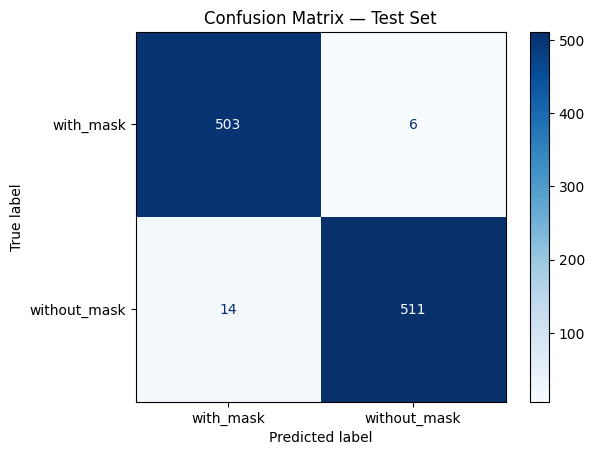

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_gen.class_indices.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

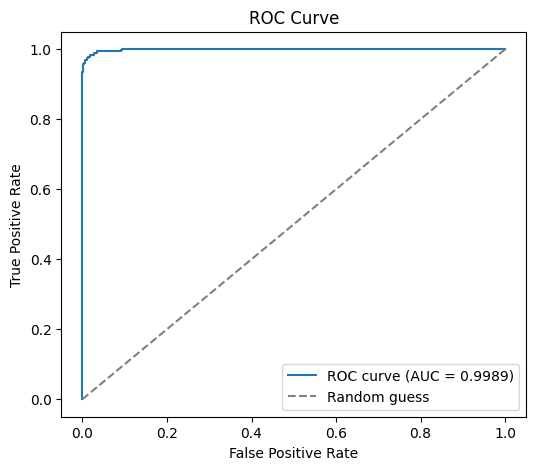

In [86]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [88]:
# Baseline: majority-class predictor (always predicts the most common class)
majority_class = pd.Series(y_true).mode()[0]
baseline_preds = np.full_like(y_true, majority_class)
baseline_acc = accuracy_score(y_true, baseline_preds)

print(f"Baseline (majority-class) accuracy: {baseline_acc:.4f}")
print(f"Final model accuracy:               {acc:.4f}")
print(f"Improvement over baseline:          {(acc - baseline_acc)*100:.2f} percentage points")

Baseline (majority-class) accuracy: 0.5077
Final model accuracy:               0.9807
Improvement over baseline:          47.29 percentage points


In [89]:
model.save("face_mask_detector.h5")
print("Model saved.")

Model saved.
